# Introduction

This notebook builds on top of the Pose Determiner notebook, where the methodology for NBV calculation is demonstrated. In this notebook, we will gor through the whole  pipeline similar to the Pose Determner notebook, but with some of the unsolved challenges from the aforementioned notebook solved.

We'll start off by importing in the relevant librarie and defining some Primary Helper Functions

In [2]:
import time
begin = time.time()
"""
    Get all the necessary modules  mentioned above loaded in
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import matplotlib.gridspec as gridspec

# Import ZoeDepth
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize

# Import Open3D
import open3d as o3d

# Import Pyvista and set backend-trame
import pyvista as pv
pv.set_jupyter_backend('trame')

# Import RemBG
from rembg import remove, new_session

# Import 
from skimage import feature, io, color, img_as_float, filters
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.filters import sobel, scharr
from skimage.exposure import adjust_log

from sklearn.cluster import MeanShift
from scipy.spatial.transform import Rotation as R

%matplotlib notebook

"""
    Define Some Helper Functions for Coveniences
"""

def load_image(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def compute_depth(image, dev="cpu"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    DEVICE = "cuda" if dev == "cuda" and torch.cuda.is_available() else "cpu"
    zoe.to(DEVICE)
    depth_numpy = zoe.infer_pil(image)  # as numpy
    zoe.to('cpu')
    torch.cuda.empty_cache()  # Clear unused cached memory
    return depth_numpy

def show_image(image, label, colorbar=True):
    """
    Display an image with an optional colorbar.

    Parameters:
    image : array-like
        The image data. This can be any array-like object that is interpretable by `imshow`.
    label : str
        The title label for the image. This text will be displayed above the image.
    colorbar : bool, optional
        A flag to indicate whether a colorbar should be displayed alongside the image.
        If True (default), a colorbar is displayed. If False, no colorbar is shown.

    """
    _, ax = plt.subplots(layout="constrained")
    imgPlot = ax.imshow(image)
    ax.set_title(label)
    if colorbar: plt.colorbar( imgPlot, ax=ax )
        

def create_mask(image):
    '''
        Create a Mask out of an image
    '''
    model_name = "u2net" # sam, u2net, silueta, isnet-general-use
    session = new_session(model_name)
    mask = remove(image, only_mask=True, post_process_mask=True)
    return mask
    
def mask_out(mask, _img):
    '''
        Masks out part of the image
    '''
    to_mask= np.copy(_img) # create a copy of the depth map
    to_mask[mask == 0] = 0
    return to_mask

def grayscale_to_rgb(grayscale_image):
    """
    Convert a grayscale image to an RGB image by replicating the grayscale values across all three channels.

    Parameters:
    - grayscale_image (numpy.ndarray): The input grayscale image.

    Returns:
    - rgb_image (numpy.ndarray): The resulting RGB image.
    """
    # Stack the grayscale image across three channels
    rgb_image = np.stack((grayscale_image,) * 3, axis=-1)
    return rgb_image

# Creating a custom Exception based on widths
class UnmatchedDimensionsException(Exception):
    pass
    
if 'zoe' not in globals():
    conf = get_config("zoedepth", "infer")
    zoe = build_model(conf)


img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


# Loading in the Viewpoint


The orginal input image is loaded in throught the load_image() and cached to the variable image_col function. Its depth map is then computed and and cached in the variable image_dep. Backgrounds of the two are then removed to retain the foreground(target object) as image_col_m and image_dep_m respectively.

EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecut

<IPython.core.display.Javascript object>


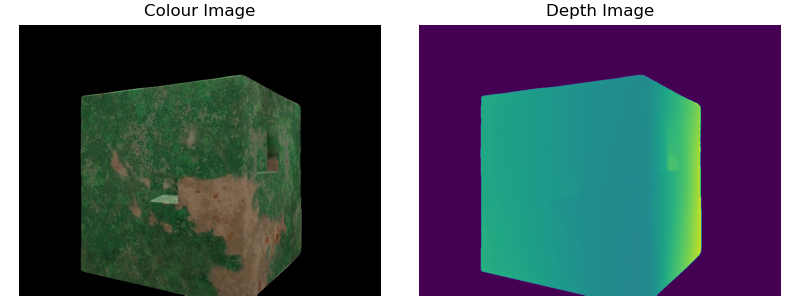

In [3]:
# Load Image from the ./testImages directory
image_col = load_image("33.jpg")

# Compute Depth Map
image_dep = compute_depth(image_col, dev="cuda")

# Mask out both Color and Depth images
mask = create_mask(image_col)
image_col_m = mask_out(mask, image_col)
image_dep_m = mask_out(mask, image_dep)

fig, axs = plt.subplots( 1, 2, figsize=(8,3), layout="constrained" )
for title, ax, img in zip([ "Colour Image", "Depth Image" ], axs, [ image_col_m, image_dep_m ]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    
    
img_width = image_col.shape[1]
img_height = image_col.shape[0]

# Calculate Occupancy
area = image_dep_m[image_dep_m > 0].size
occupancy = area/image_dep_m.size
occ_R = int(np.sqrt(area / np.pi))

# Calculate Camera Intrinsics
focal_l = 6.0
fx, fy = (focal_l *  img_width/6.287, focal_l *  img_width/6.287)
cx, cy = ( img_width/2, img_height/2 )
intrinsics = o3d.camera.PinholeCameraIntrinsic(img_width, img_height, fx, fy, cx, cy)

The `Occ_R` is represents the radius of the target object in the image a a fraction of the whole image.

# Compute Features/Regions of Interest

At this point updates from the previous notebook can be noted. For starters, we stick to the use of Difference of Gaussians(DoG) for calculations of Blobs. DoG combines the best of both Difference of Hessians and Laplacian of Gradients by being more accurate than DoH and faster than LoG. 

<IPython.core.display.Javascript object>


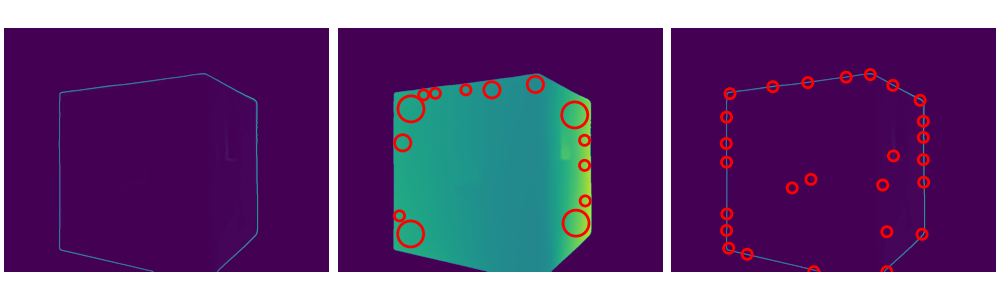

In [6]:
def add_patches_to_plot(ax, blob_list):
    for blob in blob_list:
        y, x, r = blob
        c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
        ax.add_patch(c)

# Initialise Sigma Values
min_sigma = int(occ_R*.05)
max_sigma = int(occ_R*.15)

# Compute the Edge map
edge_map = adjust_log(sobel(image_dep_m, mask=None,  axis=[0,1]))

# Compute blobs from the Depth Map
depth_map_blobs = blob_dog(image_dep_m, min_sigma=min_sigma, max_sigma=max_sigma, threshold=.1)

# Compute blobs from the Edge Map
edge_map_blobs = blob_dog(edge_map, min_sigma=min_sigma, max_sigma=max_sigma, threshold=.001)


fig, axs = plt.subplots(1, 3, figsize=(10,3), layout="constrained")

for _ax, _img, _blobs in zip(axs, [edge_map, image_dep_m, edge_map], [[], depth_map_blobs, edge_map_blobs ]):
    add_patches_to_plot(_ax, _blobs)
    _ax.imshow(_img)
    _ax.axis("off")


<IPython.core.display.Javascript object>


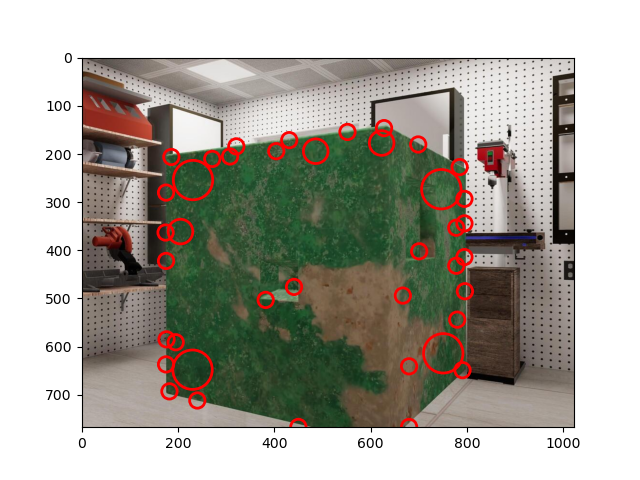

In [8]:
plt.figure()
plt.imshow(image_col)
all_blobs = np.concatenate( (depth_map_blobs, edge_map_blobs) )
add_patches_to_plot( plt.gca(), all_blobs )

## Distilling the ROIs
Figure 3 shows all the blobs from both the depth map and edge map. It can be noted that a good number seem to overlap and are thus redundant. There are 3 ways that this can be mitigated:
    

1. __Clustering and Merging:__ Apply clustering algorithms like DBSCAN or hierarchical clustering to group nearby blobs. Once clustered, you can either merge blobs in the same cluster into a single blob or represent them by a central or representative blob. This approach is effective when multiple detected blobs actually belong to the same object.

2. __Spatial Consistency Check:__ Analyze the spatial distribution of blobs. Blobs that are too close to each other and have similar characteristics can be merged or one of them can be discarded.

## Mean Shift Clustering
Mean shift clustering aims to discover "blobs" in a smooth density of samples. It is a centroid-based algorithm, which works by updating candidates for centroids to be the mean of the points within a given region. These candidates are then filtered in a post-processing stage to eliminate near-duplicates to form the final set of centroids.

## Aggregations
The Mean-shift clustering algorithm returns and nd.array with a shape of (_,2) that contains the centers for each cluster. "`_`" is the number of cluster found so far. But we want a result with the shape of (_, 3) where the third element(index:2) is indicative of the size of the cluster. This size need be in radius.

1. For each cluster, get all its blobs coordinate i.e their x and y.
2. For each clust, find the min and max across the x and y coordinates respectively to get bounding box dimensions
3. Use the Pythagorean theorem to find the diagonal, then half it.

In [12]:
selected_bandwidth = max_sigma * np.pi

# Applying Mean Shift Clustering
meanshift = MeanShift(bandwidth=selected_bandwidth)
meanshift.fit(all_blobs[:,:2])
labels = meanshift.labels_
cluster_centers = meanshift.cluster_centers_
n_clusters = len(cluster_centers)

In [13]:
indices = np.where(labels == 7)
print(labels)
print(len(all_blobs))

[5 2 5 3 1 0 0 3 1 1 1 2 4 4 2 7 0 0 5 1 0 1 0 3 5 2 2 3 4 3 3 1 1 1 4 0 6
 0 6 5]
40


<IPython.core.display.Javascript object>


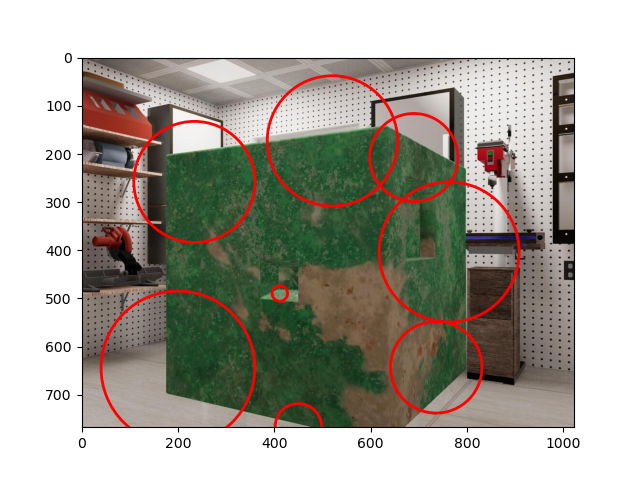

In [14]:
blobs_dict = dict()
for label, blob in zip(labels, all_blobs):
    if label in blobs_dict:
        blobs_dict[label].append(blob)
    else:
        blobs_dict[label] = [blob]

blobs_radii = {}
# Loop over Clusters
for key, blobs in blobs_dict.items():
    _blobs = np.asarray(blobs)    
    if( len(blobs) == 1 ):
        radius = blob[2]
    else:
        x_len = max(_blobs[:,0]) - min(_blobs[:,0])
        y_len = max(_blobs[:,1]) - min(_blobs[:,1])
        radius =  np.sqrt( y_len**2 + x_len**2)/2 + np.mean(_blobs[:,2:])
    blobs_radii[key] = radius 
    
# Form a Blob Structure (x,y radius)
new_blob_list = np.column_stack([cluster_centers, np.array( list(blobs_radii.values()), dtype=float )])

plt.figure()
plt.imshow(image_col)
add_patches_to_plot( plt.gca(), new_blob_list )


## DBSCAN
DBSCAN - Density-Based Spatial Clustering of Applications with Noise. Finds core samples of high density and expands clusters from them. Good for data which contains clusters of similar density.

In [17]:
from sklearn.cluster import DBSCAN

selected_eps = max_sigma
dbscan = DBSCAN(eps=selected_eps, min_samples=2)
dbscan.fit(all_blobs[:,:2])
labels = dbscan.labels_

labels

array([-1, -1, -1, -1, -1,  0,  1,  2,  3,  4,  4,  5,  6, -1, -1, -1, -1,
        1, -1, -1,  0,  4, -1, -1, -1,  5, -1, -1,  6,  2, -1,  3, -1, -1,
       -1, -1, -1, -1, -1, -1])

Unfortunately DBSCAN identifies alot of the blobs as noise.

## Calculation of Poses

Now we have a list of RoIs. We can now loop over them while calculating their poses.

In [15]:
def isolate_image(image, roi):
    # Extracting the center (y, x) and radius
    y, x, radius = roi
    
    # Calculating the square bounds
    top_y = max(int(y - radius), 0)
    left_x = max(int(x - radius), 0)
    bottom_y = min(int(y + radius), image.shape[0])
    right_x = min(int(x + radius), image.shape[1])

    # Create 
    masked = np.zeros_like(image)    
    cropped_image = image[top_y:bottom_y, left_x:right_x]
    masked[top_y:bottom_y, left_x:right_x] = cropped_image

    return masked

def create_point_cloud(extractions, focal_l = 6):
    img_rgb, img_dep = extractions
    
    # Scaling factor for the depth image
    _scale = 1000
    
    color_raw_m = o3d.geometry.Image(img_rgb)
    depth_raw_m =  o3d.geometry.Image(img_dep*_scale) 

    # Create RGBD 
    rgbd_image_m = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_raw_m, 
        depth_raw_m
    )

    # Create Point Cloud
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image( rgbd_image_m, intrinsics )

    # Estimate Normals
    pcd.estimate_normals( search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=.1, max_nn=30))
    pcd.orient_normals_towards_camera_location()

    # Create Numpy Arrays for the points and corresponding normals.
    pcd_p = np.asarray(pcd.points)
    pcd_n = np.asarray(pcd.normals)
    
    return pcd_p, pcd_n

def retrieve_normal(points, normals):
    # Calculate the centroid
    centroid = np.mean(points, axis=0)

    # Find the index of the point closest to the centroid
    distances = np.linalg.norm(points - centroid, axis=1)
    closest_point_index = np.argmin(distances)

    # Get the normal at the closest point
    closest_normal = normals[closest_point_index]
    
    return centroid, closest_normal

def add_normal_to_plotter(plotter, point, normal, col="red"):
    arrow = pv.Arrow(start=point, direction=normal, scale=.2)  # Adjust scale as needed
    plotter.add_mesh(arrow, color=col)

def normalise_vector(vec):
    norm = np.linalg.norm(vec)
    if norm == 0: 
        normalized_v = vec
    else:
        normalized_v = vec / norm
    
    return normalized_v
    
# Get Baselines for Blob Radius and Primar Pose Distance
WD = np.min(image_dep_m[image_dep_m > 0])
Rad = np.max(new_blob_list[:,2])

In [16]:
# Prepare the Point Cloud
viewpoint_points, viewpoint_normals = create_point_cloud( [ image_col_m, image_dep_m ] )
viewpoint_centroid = np.mean(viewpoint_points, axis=0)

plotter = pv.Plotter()
vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=1, render_points_as_spheres=True)

# Hold all the Poses
local_poses = list()

for blob in new_blob_list:
    # Get Blob Centroid and Normal
    roi_col = isolate_image( image_col_m, blob )
    roi_dep = isolate_image( image_dep_m, blob )
    points, normals = create_point_cloud( [ roi_col, roi_dep ] )
    centroid, normal = retrieve_normal(points, normals)
    # Create and add a sphere to represent a single point
    sphere = pv.Sphere(radius=.05, center=centroid)
    plotter.add_mesh(sphere, color='red')

    # Calculate Primary Pose Position and Orientation
    wd = np.clip( (int(blob[2])/Rad) * WD, WD/2, WD )
    priPose_loc = (normal * wd) + centroid
    priPose_rot = normalise_vector(centroid - priPose_loc)
    local_poses.append({ "pos" : priPose_loc, "rot" : priPose_rot })
    add_normal_to_plotter(plotter,priPose_loc, priPose_rot, "blue")


    # Calculate Angle Delta
    v1 = priPose_loc - centroid
    v2 = viewpoint_centroid - centroid
    dot_product = np.dot(v1, v2)
    mag_v1 = np.linalg.norm(v1)
    mag_v2 = np.linalg.norm(v2)
    angle_radians = np.arccos(dot_product / (mag_v1 * mag_v2))

    # Calculate Secondary Pose
    normal = np.cross(v1, v2)
    rot_axis = normal / np.linalg.norm(normal)
    theta = -(np.pi - angle_radians)/2
    quat = R.from_rotvec(theta * rot_axis) # Create a quaternion for the rotation
    secPose_loc = quat.apply(v1) + centroid
    secPose_rot = normalise_vector( centroid - secPose_loc )
    local_poses.append({ "pos" : secPose_loc, "rot" : secPose_rot })
    add_normal_to_plotter(plotter,secPose_loc, secPose_rot, "yellow")

# Create and add a sphere to represent a single point
sphere = pv.Sphere(radius=.05, center=viewpoint_centroid)

plotter.add_mesh(sphere, color='green')
plotter.view_xz()
plotter.show_grid()
plotter.show_axes()
plotter.show()

Widget(value="<iframe src='http://localhost:38195/index.html?ui=P_0x7f2bdd026f40_0&reconnect=auto' style='widt…

The working distance for each region of interest is clamped between `0.5WD` and `WD`. However the lower clamp should be determined more by the camera sensor limitations.

# Translating to Unity's Coordinate Frame

The new poses have the real camera's viewpoint as their reference coordinate frame. That makes the poses inadequate to be applied to the real camera. Furthermore, the orientation is given as a normal vector which is not standard. The real camera's viewpoint is however part of a nother coordinate frame, and in the case of Unity Engine, it is part of the World Coordinate frame and has its own set of transform parameters(position and rotation).

Thus, the normal vectors have to be translated to a standardised form of representing rotations(such as quaternions)then transform the new poses' location and rotation into Unity's world coordinate frame.

   **NB: These vectors show where the camera is pointing, but not the camera's roll around its axis.**

In [43]:
cameraTransform =  {
    "position": [0.81, 0.63, -0.47],
    "rotation": [0.07319, -0.49821, 0.04225, 0.86293]
}
cam_pos = cameraTransform["position"]
cam_rot = cameraTransform["rotation"]
unityTrans = dict()

def vector_to_quaternion(dir_vec):           
    forward_vec = np.array([0, 0, 1])  # Assuming Z-axis is forward
    cross_prod = np.cross(forward_vec, dir_vec)
    dot_prod = np.dot(forward_vec, dir_vec)
    x, y, z = cross_prod
    w = np.sqrt(np.linalg.norm(forward_vec)**2 * np.linalg.norm(dir_vec)**2) + dot_prod
    quat = np.array([x, y, z, w])
    return quat / np.linalg.norm(quat)
    
local_rot_quat = vector_to_quaternion(priPose_loc)
unityTrans["position"] = cam_pos + priPose_loc
unityTrans["rotation"] = (R.from_quat(cam_rot) * R.from_quat(local_rot_quat)).as_quat()

In [61]:
cameraTransform =  {
    "position": [0.81, 0.63, -0.47],
    "rotation": [0.07319, -0.49821, 0.04225, 0.86293]
}
cam_pos = cameraTransform["position"]
cam_rot = cameraTransform["rotation"]

Poses = list()

for pose in local_poses:
    local_rot_quat = vector_to_quaternion(pose['rot'])
    _pot = cam_pos + pose['pos']
    _rot = (R.from_quat(cam_rot) * R.from_quat(local_rot_quat)).as_quat()
    Poses .append({ "pos" : _pot, "rot" : _rot })
Poses

[{'pos': array([1.74733125, 1.11633099, 1.11972123]),
  'rot': array([ 0.29069888, -0.91510615,  0.10293722,  0.25976685])},
 {'pos': array([0.27301013, 1.8509135 , 1.682569  ]),
  'rot': array([ 0.74962775, -0.10460986,  0.44725406,  0.47652788])},
 {'pos': array([ 1.29416832,  0.58195197, -0.35437688]),
  'rot': array([ 0.01356036, -0.62075453, -0.00644198,  0.78386123])},
 {'pos': array([ 1.60530681,  1.31930394, -0.12113433]),
  'rot': array([ 0.24551292, -0.6925036 ,  0.11573688,  0.66840642])},
 {'pos': array([0.53985394, 0.76378405, 0.19296773]),
  'rot': array([ 0.02654187, -0.3961769 ,  0.02663895,  0.91740381])},
 {'pos': array([0.47626776, 1.24535765, 0.31633433]),
  'rot': array([ 0.28109522, -0.32614601,  0.17795008,  0.8848435 ])},
 {'pos': array([0.15746284, 0.50076661, 0.20897351]),
  'rot': array([ 0.02411514, -0.28453644,  0.03667772,  0.95765976])},
 {'pos': array([-0.21692856,  0.25764663,  0.63750363]),
  'rot': array([-0.12201221, -0.01734383, -0.02333998,  0.9921

In [48]:
local_poses[1]['rot']

array([ 0.15919578, -0.89200188, -0.42307134])

In [35]:
cam_rot

[0.07319, -0.49821, 0.04225, 0.86293]

In [117]:
np.fromstring(cameraTransform['position'], dtype=float, sep=',')

/tmp/ipykernel_16473/2524752009.py:1: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  np.fromstring(cameraTransform['position'], dtype=float, sep=',')


array([], dtype=float64)

In [15]:
wd

0.933362300789721